# CNNでひらがなを分類しよう: ETL8G

この notebook では，ETL8G の手書きひらがなを CNN で分類する。
MNIST Digits よりクラス数が多く，字の形も似ているので，かなり難しくなる。

完璧な精度を目指すより，「難しいデータでは何が起きるか」を観察することを大事にする。


## MNIST との違い

MNIST は 10 クラスだが，ここでは 75 種類のひらがなを扱う。
「は・ほ・ま」「ぬ・め」「さ・き」のように，人間でも形の近さを感じる文字がある。

そのため，accuracy が MNIST より低くても自然である。
予測例や間違い方を見ると，モデルがどこで迷っているかを考えやすい。


## 準備

この notebook は，ETL8G の手書きひらがなデータを使う。
ETL8G は使用条件への同意が必要なので，自動ではダウンロードしない。
公式ページから取得したファイルを `data/ETL8G/` に置いてから実行する。

コードセルには，理解するためのコードと，準備のためのコードが混ざっている。
このページで特に読んでほしいのは，`nn.Sequential` で書いた小さな CNN，padding の実験，データ拡張の設定である。
ETL8G を読み込む長いコードや，図を描くためだけのコードは，ページ上では折りたたんである。
必要になったら開けばよい。

ETL8G は MNIST よりずっと難しい。
最初から高い accuracy を期待するより，訓練のログと予測例を見て，モデルがどこで迷うかを観察しよう。


In [1]:
from __future__ import annotations

import json
import random
import re
import struct
import tempfile
import unicodedata
import warnings
import zipfile
from pathlib import Path

warnings.filterwarnings("ignore", category=Warning, module=r"tqdm\.auto")
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import torch
import transformers
from jaxtyping import Float, Int64
from PIL import Image
from sklearn.metrics import accuracy_score
from torch import nn
from torch.utils.data import Dataset, Subset
from torchvision import transforms
from transformers import Trainer, TrainingArguments
from transformers.trainer_utils import EvalPrediction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DATA_ROOT = Path("data") if Path("data").exists() else Path("../data")

JAPANESE_FONT_CANDIDATES = [
    "Hiragino Sans",
    "Hiragino Maru Gothic Pro",
    "YuGothic",
    "Noto Sans CJK JP",
    "Arial Unicode MS",
]
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
for font_name in JAPANESE_FONT_CANDIDATES:
    if font_name in available_font_names:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False


print(f"device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")


device: mps
PyTorch: 2.11.0
Transformers: 5.8.1


## ETL8G を用意する

ETL8G は，日本語の手書き文字を集めたデータである。
この notebook では，その中からひらがなとして読める文字だけを取り出す。

使う前に，公式ページで使用条件に同意して ETL8G をダウンロードする。
この notebook では，次のどちらかの形で置いてあればよい。

```text
data/
  ETL8G.zip
```

または，すでに展開済みなら次の形でもよい。

```text
data/ETL8G/
  ETL8G_01
  ETL8G_02
  ...
  ETL8G_33
  ETL8INFO
```

`data/ETL8G.zip` があり，`data/ETL8G/` がまだない場合は，次の準備コードが自動で展開する。
環境によってファイル名やファイル数が少し違ってもよい。
この notebook は `data/ETL8G/` の中から，ETL8G のデータファイルを探す。

次のセルは，ETL8G の特殊なファイル形式を PyTorch で使える形に直すための準備コードである。
かなり長いので，表示では折りたたんである。
`zipfile`，`struct`，JIS コード，Unicode という言葉が出てくるが，ここでは深追いしなくてよい。
授業では，このセルを実行すると「ZIP からデータを用意し，ひらがなの画像とラベルが取り出せる」と分かればよい。


In [2]:
ETL8G_DIR = DATA_ROOT / "ETL8G"
ETL8G_ZIP_PATH = DATA_ROOT / "ETL8G.zip"
ETL8G_RECORD_SIZE = 8199
ETL8G_RECORD_FORMAT = ">2H8sI4B4H2B30x8128s11x"
ETL8G_IMAGE_SIZE = (128, 127)
MODEL_IMAGE_SIZE = (28, 28)
TRAIN_SAMPLES_PER_LABEL = 80
EVAL_SAMPLES_PER_LABEL = 20


def prepare_etl8g_root(data_root: Path) -> Path:
    """ETL8G の展開済みディレクトリを用意する.

    Args:
        data_root: `data` ディレクトリ.

    Returns:
        ETL8G の展開済みディレクトリ.

    Raises:
        FileNotFoundError: `ETL8G` ディレクトリも `ETL8G.zip` も見つからない場合.
    """
    etl8g_dir = data_root / "ETL8G"
    etl8g_zip = data_root / "ETL8G.zip"

    if etl8g_dir.exists():
        print(f"ETL8G directory: {etl8g_dir}")
        return etl8g_dir

    if etl8g_zip.exists():
        print(f"extracting {etl8g_zip} ...")
        with zipfile.ZipFile(etl8g_zip) as archive:
            archive.extractall(data_root)
        print(f"ETL8G directory: {etl8g_dir}")
        return etl8g_dir

    raise FileNotFoundError(
        "ETL8G が見つかりません。"
        f"{etl8g_dir} に展開するか，{etl8g_zip} を置いてください。"
    )


ETL8G_ROOT = prepare_etl8g_root(DATA_ROOT)


def find_etl8g_data_files(root: Path) -> list[Path]:
    """ETL8G のバイナリデータファイルを探す.

    Args:
        root: ETL8G を展開したディレクトリ，またはデータファイルそのもの.

    Returns:
        ETL8G の固定長レコードとして読めるファイルのリスト.
    """
    if root.is_file():
        candidates = [root]
    elif root.exists():
        candidates = [path for path in root.rglob("*") if path.is_file()]
    else:
        candidates = []

    data_files = []
    skipped_suffixes = {".csv", ".jpg", ".jpeg", ".png", ".txt", ".zip"}
    for candidate in candidates:
        if candidate.name.upper().endswith("INFO"):
            continue
        if candidate.suffix.lower() in skipped_suffixes:
            continue
        file_size = candidate.stat().st_size
        if file_size > 0 and file_size % ETL8G_RECORD_SIZE == 0:
            data_files.append(candidate)
    return sorted(data_files)


def jis0208_code_to_character(code: int) -> str | None:
    """JIS X 0208 の2バイトコードを Unicode 文字に直す.

    Args:
        code: ETL8G の ID 部分に入っている JIS X 0208 コード.

    Returns:
        変換できた1文字。変換できない場合は None.
    """
    raw = code.to_bytes(2, byteorder="big")
    try:
        return (b"$B" + raw + b"(B").decode("iso2022_jp")
    except UnicodeDecodeError:
        return None


def is_hiragana_label(character: str | None) -> bool:
    """ETL8G から取り出したラベルがひらがなかどうかを判定する."""
    if character is None or len(character) != 1:
        return False
    return unicodedata.name(character, "").startswith("HIRAGANA LETTER ")


def decode_etl8g_image(payload: bytes) -> Image.Image:
    """ETL8G の4bit画像データを PIL 画像に直す.

    Args:
        payload: 1レコードに含まれる画像部分の bytes.

    Returns:
        白い背景に黒い文字として見える PIL 画像.
    """
    image = Image.frombytes("F", ETL8G_IMAGE_SIZE, payload, "bit", 4).convert("L")
    return Image.eval(image, lambda pixel: 255 - pixel * 16)


class ETL8GHiraganaDataset(Dataset[tuple[Image.Image, int]]):
    """ETL8G から手書きひらがなだけを取り出す PyTorch Dataset."""

    def __init__(self, root: Path) -> None:
        """Dataset を初期化する.

        Args:
            root: ETL8G を展開したディレクトリ，またはデータファイルそのもの.

        Raises:
            FileNotFoundError: ETL8G のデータファイルが見つからない場合.
            ValueError: ETL8G の中からひらがな画像を見つけられない場合.
        """
        data_files = find_etl8g_data_files(root)
        if not data_files:
            raise FileNotFoundError(
                "ETL8G のデータファイルが見つかりません。"
                f"{root} に ETL8G が展開されているか確認してください。"
            )

        self.images: list[Image.Image] = []
        raw_labels: list[str] = []

        for data_file in data_files:
            with data_file.open("rb") as file:
                while record := file.read(ETL8G_RECORD_SIZE):
                    unpacked = struct.unpack(ETL8G_RECORD_FORMAT, record)
                    character = jis0208_code_to_character(unpacked[1])
                    if not is_hiragana_label(character):
                        continue
                    raw_labels.append(character)
                    self.images.append(decode_etl8g_image(unpacked[14]))

        if not raw_labels:
            raise ValueError(
                "ETL8G は読めましたが，ひらがなのレコードが見つかりませんでした。"
                "展開したファイルが ETL8G の多値画像データか確認してください。"
            )

        self.classes = list(dict.fromkeys(raw_labels))
        self.class_to_idx = {label: index for index, label in enumerate(self.classes)}
        self.targets = [self.class_to_idx[label] for label in raw_labels]

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> tuple[Image.Image, int]:
        return self.images[index].copy(), self.targets[index]


class TransformedImageDataset(Dataset[tuple[Float[torch.Tensor, "1 28 28"], int]]):
    """PIL 画像の dataset に前処理をかけ，Tensor として返す dataset."""

    def __init__(self, dataset: Dataset[tuple[Image.Image, int]], transform: transforms.Compose) -> None:
        """Dataset を初期化する.

        Args:
            dataset: PIL 画像と整数ラベルを返す dataset.
            transform: PIL 画像をモデル入力 Tensor に変える前処理.
        """
        self.dataset = dataset
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> tuple[Float[torch.Tensor, "1 28 28"], int]:
        image, label = self.dataset[index]
        return self.transform(image), int(label)


def make_label_balanced_subsets(
    dataset: ETL8GHiraganaDataset,
    train_per_label: int,
    eval_per_label: int,
) -> tuple[Subset, Subset]:
    """各文字から同じ枚数ずつ取り，訓練用と評価用に分ける.

    Args:
        dataset: ETL8G のひらがな dataset.
        train_per_label: 1文字あたりの訓練枚数.
        eval_per_label: 1文字あたりの評価枚数.

    Returns:
        訓練用 subset と評価用 subset.
    """
    generator = torch.Generator().manual_seed(SEED)
    targets = torch.tensor(dataset.targets)
    train_indices: list[int] = []
    eval_indices: list[int] = []

    for label_index in range(len(dataset.classes)):
        label_indices = torch.where(targets == label_index)[0]
        shuffled = label_indices[torch.randperm(len(label_indices), generator=generator)].tolist()
        train_indices.extend(shuffled[:train_per_label])
        eval_indices.extend(shuffled[train_per_label:train_per_label + eval_per_label])

    return Subset(dataset, train_indices), Subset(dataset, eval_indices)


def invert_grayscale_tensor(tensor: torch.Tensor) -> torch.Tensor:
    """白背景の画像を，背景0・文字が正の値になるように反転する."""
    return 1.0 - tensor


base_transform = transforms.Compose([
    transforms.Resize(MODEL_IMAGE_SIZE, interpolation=Image.Resampling.BILINEAR),
    transforms.ToTensor(),
    transforms.Lambda(invert_grayscale_tensor),
])

train_transform = transforms.Compose([
    transforms.Resize(MODEL_IMAGE_SIZE, interpolation=Image.Resampling.BILINEAR),
    transforms.RandomAffine(
        degrees=4,
        translate=(0.04, 0.04),
        scale=(0.96, 1.04),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=255,
    ),
    transforms.ToTensor(),
    transforms.Lambda(invert_grayscale_tensor),
])

eval_transform = base_transform

etl8g_full = ETL8GHiraganaDataset(root=ETL8G_ROOT)
train_subset_raw, eval_subset_raw = make_label_balanced_subsets(
    etl8g_full,
    train_per_label=TRAIN_SAMPLES_PER_LABEL,
    eval_per_label=EVAL_SAMPLES_PER_LABEL,
)
train_dataset_raw = TransformedImageDataset(train_subset_raw, transform=train_transform)
eval_dataset_raw = TransformedImageDataset(eval_subset_raw, transform=eval_transform)
label_names = etl8g_full.classes

print("dataset: ETL8G hiragana")
print("all hiragana samples:", len(etl8g_full))
print("train samples:", len(train_dataset_raw))
print("eval samples:", len(eval_dataset_raw))
print("labels:", " ".join(label_names))


ETL8G directory: ../data/ETL8G


dataset: ETL8G hiragana
all hiragana samples: 12075
train samples: 6000
eval samples: 1500
labels: あ い う え お か が き ゃ ぎ く ぐ け げ こ ご さ ざ し ゅ じ す ず せ ぜ そ ぞ た だ ち ょ ぢ つ づ て で と ど な に っ ぬ ね の は ば ぱ ひ び ぴ ふ ぶ ぷ へ べ ぺ ほ ぼ ぽ ま み む め も や ゆ よ ら り る れ ろ わ を ん


## データを見てみる

コンピュータにとって，画像は「数字がたくさん並んだ表」である。
ETL8G の元画像は大きいので，この notebook では授業中に速く試せるように `28 × 28` へ小さくして使う。

PyTorch では，画像を Tensor（テンソル）という形で扱う。
ここでは，1枚の画像を `1 × 28 × 28` の Tensor として扱う。

- `1` は白黒画像であることを表す。
- `28 × 28` は，画像を縦28マス，横28マスの小さなマス目として見るという意味である。

つまり，1枚の文字画像は 784 個の明るさの数字としてモデルに入る。
この notebook では，背景を `0` に近く，文字の線を正の値にしてモデルへ入れる。
こうすると，CNN は白い背景ではなく，文字の線に注目しやすくなる。

訓練用データには，後で説明するデータ拡張が入っている。
そのため，同じ画像を取り出しても，少しだけ傾きや位置が変わって見えることがある。


image shape: (1, 28, 28)
label: 0 あ


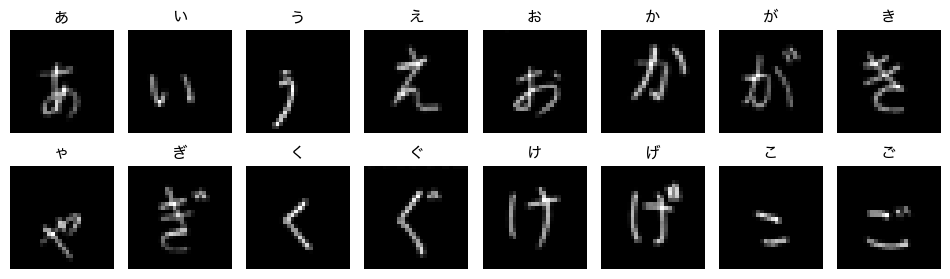

In [3]:
def show_handwritten_examples(dataset: Dataset, label_names: list[str], rows: int = 2, cols: int = 8) -> None:
    """手書き文字データの例を表示する.

    Args:
        dataset: 画像とラベルを返す PyTorch dataset.
        label_names: ラベル番号に対応する表示名.
        rows: 表示する行数.
        cols: 表示する列数.
    """
    display_count = rows * cols
    display_indices: list[int] = []
    seen_labels: set[int] = set()
    for index in range(len(dataset)):
        _, label = dataset[index]
        label_id = int(label)
        if label_id in seen_labels:
            continue
        seen_labels.add(label_id)
        display_indices.append(index)
        if len(display_indices) == display_count:
            break

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.5))
    for ax, index in zip(axes.ravel(), display_indices, strict=False):
        image, label = dataset[index]
        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(label_names[int(label)], fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_image, sample_label = eval_dataset_raw[0]
print("image shape:", tuple(sample_image.shape))
print("label:", int(sample_label), label_names[int(sample_label)])
show_handwritten_examples(eval_dataset_raw, label_names)


## データ拡張で，少し違う字も見せる

手書き文字は，人によって少しずつ違う。
少し傾くこともあるし，中心からずれることもあるし，文字の大きさも変わる。

そこで，訓練中だけ画像を少し変形して，モデルに「ちょっと違う見た目でも同じ文字だ」と練習させる。
これを**データ拡張**と呼ぶ。

この notebook では，訓練用データだけに次の変化を入れている。

- 少し回転する。
- 少し上下左右に動かす。
- 少しだけ大きくしたり小さくしたりする。

評価用データにはデータ拡張を入れない。
テスト問題まで勝手に変えてしまうと，モデルの実力を比べにくくなるからである。

まずは「同じ字が少しずつ違って見える」ことだけ確認しよう。
もっと試したい場合は，`degrees` や `translate` の値を少し変えるとよい。
ただし，大きく変えすぎると別の文字のように見えてしまう。
この notebook では，小さい CNN でも学習しやすいように，かなり控えめな変形だけを使う。
データ拡張は，モデルを鍛えるための軽いゆさぶりだと考えよう。


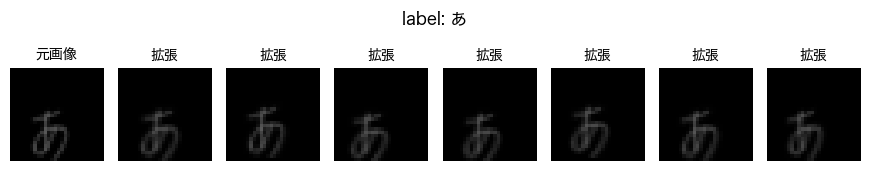

In [4]:
def show_augmentation_examples(
    raw_dataset: Dataset[tuple[Image.Image, int]],
    train_transform: transforms.Compose,
    base_transform: transforms.Compose,
    label_names: list[str],
    index: int = 0,
    count: int = 8,
) -> None:
    """同じ手書き画像を，データ拡張で少しずつ変えて表示する.

    Args:
        raw_dataset: PIL 画像とラベルを返す dataset.
        train_transform: 訓練時に使うデータ拡張込みの前処理.
        base_transform: 評価時に使う，変形なしの前処理.
        label_names: ラベル番号に対応する表示名.
        index: 表示する元画像の番号.
        count: 表示する画像数.
    """
    image, label = raw_dataset[index]
    tensors = [base_transform(image)] + [train_transform(image) for _ in range(count - 1)]
    titles = ["元画像"] + ["拡張" for _ in range(count - 1)]

    fig, axes = plt.subplots(1, count, figsize=(count * 1.1, 1.6))
    fig.suptitle(f"label: {label_names[int(label)]}", y=1.05)
    for ax, tensor, title in zip(np.atleast_1d(axes), tensors, titles, strict=True):
        ax.imshow(tensor.squeeze(0), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_augmentation_examples(train_subset_raw, train_transform, base_transform, label_names)


## `Trainer` に渡す形へそろえる

`Trainer` は，Hugging Face Transformers が用意している「学習を進める係」である。
自分で訓練ループを細かく書かなくても，データ，モデル，学習設定を渡すと訓練してくれる。

ただし，`Trainer` には「この名前でデータを渡してほしい」という約束がある。
画像は `pixel_values`，正解ラベルは `labels` という名前にする。
ここでは，その約束に合わせて dataset の返し方だけを少し変える。
この接続用コードは授業の主役ではないので，細部は最初に読み飛ばしてよい。

訓練用データは，取り出すたびに少しだけデータ拡張される。
評価用データは，毎回同じ画像として取り出される。
このように分けると，「練習では少し難しい問題を混ぜるが，テストは同じ条件で見る」という形になる。

モデルは，文字ごとの点数である `logits` と，どれくらい間違っているかを表す `loss` を返す。
`loss` が小さくなるほど，モデルは正解に近づいていると考えられる。


In [5]:
class HandwritingDatasetForTrainer(Dataset[dict[str, torch.Tensor]]):
    """手書き文字 dataset を Trainer 用の辞書形式で返す dataset."""

    def __init__(self, dataset: Dataset) -> None:
        """Dataset を初期化する.

        Args:
            dataset: 画像と整数ラベルを返す PyTorch dataset.
        """
        self.dataset = dataset

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        image, label = self.dataset[index]
        return {
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long),
        }

train_dataset = HandwritingDatasetForTrainer(train_dataset_raw)
eval_dataset = HandwritingDatasetForTrainer(eval_dataset_raw)


## 小さな CNN を作る

ここでは，授業中に試しやすい小さな CNN を使う。
目的は世界最高の精度を出すことではなく，「画像を入れると，CNN が文字の手がかりを学んでいく」ことを体験することである。

ネットワーク本体は，今まで練習してきた `nn.Sequential` で1本の流れとして書く。
この節で一番見てほしいのは，`make_tiny_cnn` の中にある `nn.Sequential(...)` である。
その下の `ImageClassifierForTrainer` は，`Trainer` に渡すための接続用の箱だと思えばよい。

`nn.Sequential` の中で起きることは次の通りである。

1. `Conv2d`：小さな窓で，線や角のような手がかりを探す。
2. `ReLU`：弱い反応を0にして，強く反応した場所を残す。
3. `MaxPool2d`：近い場所の反応をまとめて，画像を少し小さくする。
4. `Flatten`：画像の形を，1列の数字の並びに直す。
5. `Linear`：各クラスの点数 `logits` を出す。

名前は少し難しく見えるが，ひとつひとつは部品である。
高校生が最初に触るなら，`Conv2d` の出力チャンネル数，`padding`，`Dropout` の値あたりから変えるとよい。
一度に全部変えると何が効いたか分からなくなるので，1か所ずつ試そう。

ここで `Conv2d(..., kernel_size=3, padding=1)` と書いている。
`kernel_size=3` は，`3 × 3` の小さな窓で画像を見るという意味である。
`padding=1` は，画像の外側に1マス分の余白を足してから畳み込むという意味である。

padding がないと，端の画素は窓の中心になりにくく，畳み込みのたびに画像が少し小さくなる。
手書き文字では，はねや払いが端に近いこともある。
そこで今回は `padding=1` にして，`28 × 28` の大きさを保ちながら手がかりを探す。


In [6]:
def make_tiny_cnn(num_labels: int) -> nn.Sequential:
    """ETL8G ひらがな用の小さな CNN を1つの Sequential として作る.

    Args:
        num_labels: 分類するクラス数.

    Returns:
        画像からクラスごとの点数 `logits` を出す `nn.Sequential`.
    """
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 64),
        nn.ReLU(),
        nn.Linear(64, num_labels),
    )


class ImageClassifierForTrainer(nn.Module):
    """`Trainer` に合わせて `loss` と `logits` を返す接続用クラス."""

    def __init__(self, network: nn.Sequential) -> None:
        """分類モデルを初期化する.

        Args:
            network: 画像からクラスごとの点数 `logits` を出す `nn.Sequential`.
        """
        super().__init__()
        self.network = network
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(
        self,
        pixel_values: Float[torch.Tensor, "batch 1 28 28"],
        labels: Int64[torch.Tensor, "batch"] | None = None,
    ) -> dict[str, torch.Tensor]:
        """画像を分類し，必要なら損失も返す.

        Args:
            pixel_values: 入力画像のミニバッチ.
            labels: 正解ラベルのミニバッチ.

        Returns:
            `logits` と，`labels` がある場合は `loss` を含む辞書.
        """
        logits = self.network(pixel_values)
        output = {"logits": logits}
        if labels is not None:
            output["loss"] = self.loss_fn(logits, labels)
        return output


network = make_tiny_cnn(num_labels=len(label_names))
model = ImageClassifierForTrainer(network)
network


Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=75, bias=True)
)

## padding を変えると何が起きるか

padding は，画像のまわりに足す余白のことである。
`3 × 3` の窓で `28 × 28` の画像を見るとき，padding がないと出力は `26 × 26` になる。
一方，`padding=1` にすると出力は `28 × 28` のままになる。

下のセルでは，padding の値だけを変えて，出力の形がどう変わるかを確認する。
形だけを見る実験なので，中身の重みは気にしなくてよい。


In [7]:
padding_probe = torch.zeros(1, 1, 28, 28)
for padding in [0, 1, 2]:
    conv = nn.Conv2d(1, 1, kernel_size=3, padding=padding)
    output = conv(padding_probe)
    height, width = output.shape[-2:]
    print(f"padding={padding}: 28x28 -> {height}x{width}")


padding=0: 28x28 -> 26x26
padding=1: 28x28 -> 28x28
padding=2: 28x28 -> 30x30


## 途中の形だけ見てみる

CNN の中では，画像の形が少しずつ変わる。
`Conv2d` では `padding=1` を使っているので，畳み込み直後の縦横は `28 × 28` のままである。
その後，`MaxPool2d(2)` を通るたびに，縦と横の長さが半分になる。

最初は `28 × 28` の画像だが，途中で `14 × 14`，さらに `7 × 7` と小さくなる。
これは，細かいマス目そのものより，「どこにどんな手がかりがあるか」をまとめていくためである。


In [8]:
shape_check = torch.zeros(1, 1, 28, 28)
current = shape_check
print("input:", tuple(current.shape))
for layer_index, layer in enumerate(network):
    current = layer(current)
    print(f"network[{layer_index}] {layer.__class__.__name__}:", tuple(current.shape))
print("logits:", tuple(current.shape))


input: (1, 1, 28, 28)
network[0] Conv2d: (1, 16, 28, 28)
network[1] ReLU: (1, 16, 28, 28)
network[2] MaxPool2d: (1, 16, 14, 14)
network[3] Conv2d: (1, 32, 14, 14)
network[4] ReLU: (1, 32, 14, 14)
network[5] MaxPool2d: (1, 32, 7, 7)
network[6] Flatten: (1, 1568)
network[7] Linear: (1, 64)
network[8] ReLU: (1, 64)
network[9] Linear: (1, 75)
logits: (1, 75)


## `Trainer` で訓練する

ここでは 10 エポックだけ学習する。
エポックとは，訓練データをひと通り見る回数のことである。
10 エポックなら，同じ練習問題集を10周するようなイメージである。

ETL8G には漢字も入っているが，ここではひらがなだけを取り出して使う。
この notebook では，各文字から 80 枚ずつを訓練に使い，各文字から 20 枚ずつを評価に使う。
訓練用画像だけには，軽いデータ拡張を入れている。
評価用画像は，モデルの実力を見るために変形せずそのまま使う。

次のコードでは，`TrainingArguments(...)` が学習の設定，`Trainer(...)` が学習を実際に進める係である。
細かい引数を全部覚えなくてよい。
まずは「データ，モデル，設定を渡すと訓練が走る」と見ればよい。

CPU でも試しやすいように，データ数は少なめにしている。
もっと速く終わらせたい場合は，`num_train_epochs` を `3` や `5` に下げて試してもよい。
ただし，その分だけ時間もかかる。


In [9]:
def compute_accuracy(eval_pred: EvalPrediction) -> dict[str, float]:
    """Trainer の予測結果から accuracy を計算する.

    Args:
        eval_pred: Trainer が返す予測値と正解ラベル.

    Returns:
        accuracy を含む辞書.
    """
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir=tempfile.mkdtemp(prefix="etl8g-cnn-"),
    num_train_epochs=10,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    learning_rate=1e-3,
    optim="adamw_torch",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    seed=SEED,
    use_cpu=DEVICE.type == "cpu",
    dataloader_pin_memory=DEVICE.type == "cuda",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_accuracy,
)

train_output = trainer.train()
eval_metrics = trainer.evaluate(eval_dataset)
eval_metrics


{'loss': '4.32', 'grad_norm': '0.1024', 'learning_rate': '0.0009021', 'epoch': '1'}
{'eval_loss': '4.315', 'eval_accuracy': '0.02733', 'eval_runtime': '0.1717', 'eval_samples_per_second': '8736', 'eval_steps_per_second': '34.94', 'epoch': '1'}


{'loss': '4.289', 'grad_norm': '0.3112', 'learning_rate': '0.0008021', 'epoch': '2'}
{'eval_loss': '4.211', 'eval_accuracy': '0.04333', 'eval_runtime': '0.0815', 'eval_samples_per_second': '1.841e+04', 'eval_steps_per_second': '73.64', 'epoch': '2'}


{'loss': '3.984', 'grad_norm': '1.316', 'learning_rate': '0.0007021', 'epoch': '3'}
{'eval_loss': '3.635', 'eval_accuracy': '0.09667', 'eval_runtime': '0.0904', 'eval_samples_per_second': '1.66e+04', 'eval_steps_per_second': '66.4', 'epoch': '3'}


{'loss': '3.356', 'grad_norm': '3.145', 'learning_rate': '0.0006021', 'epoch': '4'}
{'eval_loss': '3.077', 'eval_accuracy': '0.1927', 'eval_runtime': '0.0867', 'eval_samples_per_second': '1.73e+04', 'eval_steps_per_second': '69.22', 'epoch': '4'}


{'loss': '2.965', 'grad_norm': '2.965', 'learning_rate': '0.0005021', 'epoch': '5'}
{'eval_loss': '2.768', 'eval_accuracy': '0.2607', 'eval_runtime': '0.0936', 'eval_samples_per_second': '1.602e+04', 'eval_steps_per_second': '64.07', 'epoch': '5'}


...

{'loss': '2.574', 'grad_norm': '4.022', 'learning_rate': '0.0003021', 'epoch': '7'}
{'eval_loss': '2.442', 'eval_accuracy': '0.3407', 'eval_runtime': '0.0871', 'eval_samples_per_second': '1.721e+04', 'eval_steps_per_second': '68.85', 'epoch': '7'}


{'loss': '2.462', 'grad_norm': '4.106', 'learning_rate': '0.0002021', 'epoch': '8'}
{'eval_loss': '2.36', 'eval_accuracy': '0.3573', 'eval_runtime': '0.078', 'eval_samples_per_second': '1.923e+04', 'eval_steps_per_second': '76.91', 'epoch': '8'}


{'loss': '2.417', 'grad_norm': '4.744', 'learning_rate': '0.0001021', 'epoch': '9'}
{'eval_loss': '2.317', 'eval_accuracy': '0.3653', 'eval_runtime': '0.0839', 'eval_samples_per_second': '1.788e+04', 'eval_steps_per_second': '71.52', 'epoch': '9'}


{'loss': '2.385', 'grad_norm': '5.057', 'learning_rate': '2.128e-06', 'epoch': '10'}
{'eval_loss': '2.3', 'eval_accuracy': '0.3727', 'eval_runtime': '0.0852', 'eval_samples_per_second': '1.761e+04', 'eval_steps_per_second': '70.45', 'epoch': '10'}
{'train_runtime': '9.189', 'train_samples_per_second': '6530', 'train_steps_per_second': '51.15', 'train_loss': '3.146', 'epoch': '10'}
{'eval_loss': '2.3', 'eval_accuracy': '0.3727', 'eval_runtime': '0.0851', 'eval_samples_per_second': '1.763e+04', 'eval_steps_per_second': '70.52', 'epoch': '10'}


{'eval_loss': 2.299604892730713,
 'eval_accuracy': 0.37266666666666665,
 'eval_runtime': 0.0851,
 'eval_samples_per_second': 17629.249,
 'eval_steps_per_second': 70.517,
 'epoch': 10.0}

## 学習の様子を見る

学習中は，`loss` と `accuracy` を見る。

- `loss` は，モデルの答えがどれくらい外れているかを表す数字である。
- `accuracy` は，何パーセント正解できたかを表す数字である。

だいたい `loss` が下がり，`accuracy` が上がっていれば，モデルは少しずつ文字の見分け方を覚えている。


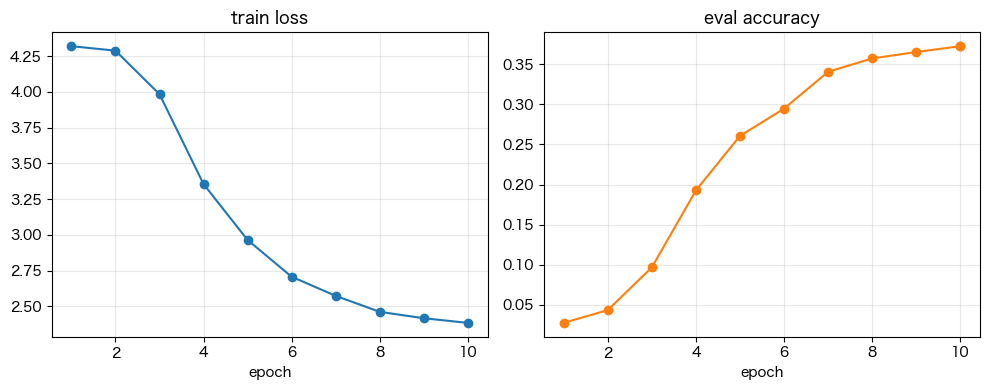

In [10]:
def plot_trainer_history(trainer: Trainer) -> None:
    """Trainer のログから loss と eval accuracy を描画する.

    Args:
        trainer: 学習済み Trainer.
    """
    history = trainer.state.log_history
    loss_points = [(item["epoch"], item["loss"]) for item in history if "loss" in item]
    accuracy_points = [(item["epoch"], item["eval_accuracy"]) for item in history if "eval_accuracy" in item]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    if loss_points:
        epochs, losses = zip(*loss_points, strict=True)
        axes[0].plot(epochs, losses, marker="o")
    axes[0].set_title("train loss")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True, alpha=0.3)

    if accuracy_points:
        epochs, accuracies = zip(*accuracy_points, strict=True)
        axes[1].plot(epochs, accuracies, marker="o", color="tab:orange")
    axes[1].set_title("eval accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_trainer_history(trainer)


## 予測例を見る

次のセルでは，評価用データの一部について，正解とモデルの予測を表示する。

最初は，細かい表よりも「どの画像をどう間違えたか」を見る方が分かりやすい。
黒いタイトルは正解，赤いタイトルは不正解である。
間違いを見ると，「この文字は人間でも紛らわしい」「この書き方はモデルが苦手そうだ」と考えられる。
機械学習では，失敗例を見ることも学習の一部である。


eval accuracy: 0.373 (559/1500)


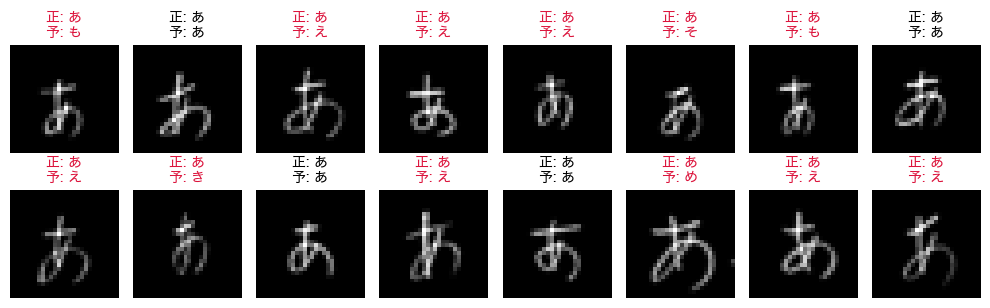

In [11]:
prediction_output = trainer.predict(eval_dataset)
y_pred = np.argmax(prediction_output.predictions, axis=1)
y_true = prediction_output.label_ids
accuracy = accuracy_score(y_true, y_pred)
print(f"eval accuracy: {accuracy:.3f} ({int((y_pred == y_true).sum())}/{len(y_true)})")

fig, axes = plt.subplots(2, 8, figsize=(10, 3.2))
for ax, index in zip(axes.ravel(), range(16), strict=False):
    image, true_label = eval_dataset_raw[index]
    predicted_label = int(y_pred[index])
    title_color = "black" if predicted_label == int(true_label) else "crimson"
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(
        f"正: {label_names[int(true_label)]}\n予: {label_names[predicted_label]}",
        color=title_color,
        fontsize=10,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()


## 自作データで試す

ここまでの `eval_dataset` は，ETL8G から分けておいた評価用データです。これはモデルの基本性能を見るためにそのまま使います。

次は別枠で，`data/自作手書き文字データ/` に保存したひらがなを「本物の未知データ」として入れてみます。黒い見出しは正解，赤い見出しは不正解です。データが増えたら，同じフォルダに追加してこのセルをもう一度実行します。


In [12]:
CUSTOM_DATASET_NAME = "自作手書き文字データ"


def normalize_path_name(name: str) -> str:
    """Unicode の濁点表現の違いをそろえて比較する."""
    return unicodedata.normalize("NFC", name)


def find_custom_handwriting_root(data_root: Path) -> Path:
    """`data` の中から自作手書き文字データのフォルダを探す."""
    target_name = normalize_path_name(CUSTOM_DATASET_NAME)
    if data_root.exists():
        for child in data_root.iterdir():
            if child.is_dir() and normalize_path_name(child.name) == target_name:
                return child
    return data_root / CUSTOM_DATASET_NAME


def path_from_metadata(root: Path, metadata: dict, key: str) -> Path | None:
    """metadata の `files` にあるファイル名を，実際の保存場所へ直す."""
    relative_name = metadata.get("files", {}).get(key)
    if not relative_name:
        return None
    candidate = root / Path(relative_name).name
    return candidate if candidate.exists() else None


def label_from_filename(path: Path) -> str | None:
    """ファイル名中の `u3042` のような Unicode 番号からラベルを読む."""
    match = re.search(r"_u([0-9A-Fa-f]{4,6})_", path.name)
    if match is None:
        return None
    return chr(int(match.group(1), 16))


def foreground_image(image: Image.Image) -> Image.Image:
    """背景が0，文字が明るい値になる1チャンネル画像へそろえる."""
    rgba = image.convert("RGBA")
    background = Image.new("RGBA", rgba.size, (0, 0, 0, 255))
    gray = Image.alpha_composite(background, rgba).convert("L")
    array = np.asarray(gray, dtype=np.uint8)
    border = np.concatenate([
        array[0, :],
        array[-1, :],
        array[:, 0],
        array[:, -1],
    ])
    if np.median(border) > 127:
        array = 255 - array
    return Image.fromarray(array, mode="L")


def custom_hiragana_transform(image: Image.Image) -> Float[torch.Tensor, "1 28 28"]:
    """自作ひらがな画像を ETL8G モデルと同じ 28x28 Tensor へ変換する."""
    image = foreground_image(image)
    image = image.resize(MODEL_IMAGE_SIZE, Image.Resampling.BILINEAR)
    return transforms.ToTensor()(image)


class CustomHandwritingDataset(Dataset[tuple[Float[torch.Tensor, "1 28 28"], int]]):
    """`data/自作手書き文字データ` から指定した種類の画像を読む dataset."""

    def __init__(self, root: Path, collection: str, label_names: list[str]) -> None:
        self.samples: list[tuple[Path, int]] = []
        self.skipped: list[Path] = []
        self.root = root
        class_to_idx = {label: index for index, label in enumerate(label_names)}

        if not root.exists():
            return

        used_image_names: set[str] = set()
        for metadata_path in sorted(root.glob(f"{collection}_*_metadata.json")):
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            if metadata.get("collection") != collection:
                continue
            label = str(metadata.get("label", ""))
            image_path = path_from_metadata(root, metadata, "etl8g_png") or path_from_metadata(root, metadata, "raw_png")
            if image_path is None or label not in class_to_idx:
                self.skipped.append(metadata_path)
                continue
            self.samples.append((image_path, class_to_idx[label]))
            used_image_names.add(image_path.name)

        for image_path in sorted(root.glob(f"{collection}_*.png")):
            if image_path.name in used_image_names or "_128x127" not in image_path.stem:
                continue
            label = label_from_filename(image_path)
            if label is None or label not in class_to_idx:
                self.skipped.append(image_path)
                continue
            self.samples.append((image_path, class_to_idx[label]))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[Float[torch.Tensor, "1 28 28"], int]:
        image_path, label = self.samples[index]
        with Image.open(image_path) as image:
            return custom_hiragana_transform(image), label


def select_prediction_grid_indices(
    predicted_labels: np.ndarray,
    true_labels: np.ndarray,
    max_images: int,
) -> list[int]:
    """表示枚数が多すぎるとき，正解例と不正解例が混ざるように選ぶ."""
    all_indices = list(range(len(true_labels)))
    if len(all_indices) <= max_images:
        return all_indices

    correct_indices = [
        index
        for index, (predicted, true) in enumerate(zip(predicted_labels, true_labels, strict=True))
        if int(predicted) == int(true)
    ]
    correct_index_set = set(correct_indices)
    wrong_indices = [index for index in all_indices if index not in correct_index_set]
    if not correct_indices or not wrong_indices:
        return all_indices[:max_images]

    correct_count = min(len(correct_indices), max_images // 2)
    wrong_count = max_images - correct_count
    selected = wrong_indices[:wrong_count] + correct_indices[:correct_count]
    return selected[:max_images]


def show_prediction_grid(
    dataset: Dataset[tuple[Float[torch.Tensor, "1 28 28"], int]],
    predicted_labels: np.ndarray,
    true_labels: np.ndarray,
    label_names: list[str],
    max_images: int = 16,
    cols: int = 8,
) -> None:
    """正解と予測を，正解なら黒，不正解なら赤で表示する."""
    selected_indices = select_prediction_grid_indices(predicted_labels, true_labels, max_images)
    display_count = len(selected_indices)
    if display_count == 0:
        print("表示できる自作データがありません。")
        return

    rows = (display_count + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.25, rows * 1.85))
    axes_array = np.atleast_1d(axes).ravel()
    for ax in axes_array:
        ax.axis("off")

    for ax, index in zip(axes_array, selected_indices, strict=False):
        image, true_label = dataset[index]
        predicted_label = int(predicted_labels[index])
        true_label = int(true_labels[index])
        title_color = "black" if predicted_label == true_label else "crimson"
        ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
        ax.set_title(
            f"正: {label_names[true_label]}\n予: {label_names[predicted_label]}",
            color=title_color,
            fontsize=10,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.show()


custom_handwriting_root = find_custom_handwriting_root(DATA_ROOT)
custom_hiragana_dataset_raw = CustomHandwritingDataset(
    root=custom_handwriting_root,
    collection="hiragana",
    label_names=label_names,
)
custom_hiragana_dataset = HandwritingDatasetForTrainer(custom_hiragana_dataset_raw)

print("custom data directory:", custom_handwriting_root)
print("custom hiragana samples:", len(custom_hiragana_dataset_raw))
print("skipped files:", len(custom_hiragana_dataset_raw.skipped))


custom data directory: ../data/自作手書き文字データ
custom hiragana samples: 47
skipped files: 0


custom hiragana accuracy: 0.085 (4/47)


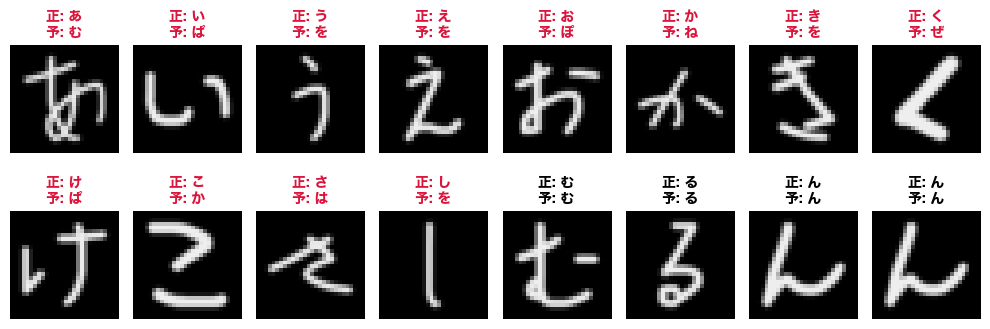

In [13]:
if len(custom_hiragana_dataset_raw) == 0:
    print("自作ひらがなデータがまだありません。追加したら，このセルをもう一度実行してください。")
else:
    custom_prediction_output = trainer.predict(custom_hiragana_dataset)
    custom_y_pred = np.argmax(custom_prediction_output.predictions, axis=1)
    custom_y_true = custom_prediction_output.label_ids
    custom_accuracy = accuracy_score(custom_y_true, custom_y_pred)
    correct_count = int((custom_y_pred == custom_y_true).sum())
    print(
        f"custom hiragana accuracy: {custom_accuracy:.3f} "
        f"({correct_count}/{len(custom_y_true)})"
    )
    show_prediction_grid(
        custom_hiragana_dataset_raw,
        custom_y_pred,
        custom_y_true,
        label_names,
        max_images=16,
        cols=8,
    )


## まとめ

この notebook では，ETL8G からひらがなだけを取り出し，小さな CNN で分類した。

- ひらがな分類は MNIST よりクラス数が多く，似た形の文字も多い。
- 白背景の画像は，背景0・文字が正の値になるように反転してから使う。
- データ拡張は強くしすぎず，少し傾く・少しずれる程度にした。
- `nn.Sequential` で CNN の部品を上から順に並べ，`Trainer` で学習した。
- 精度だけでなく，予測例と間違い方を見ることが大事である。
